# Load modules

In [72]:
from glob import glob
from datetime import datetime 
import xarray as xr 
import numpy as np 
import seawater as sw
from tqdm import tqdm
import seaborn as sns

#For plotting
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap
import cmocean 
from shapely.geometry.polygon import Polygon

# Define directories

In [23]:
main_path = '/Users/solangecoadou/Desktop/Desktop/Thesis/Data_QUICCHE/'
path_save = '/Users/solangecoadou/Desktop/Desktop/Thesis/Figure_QUICCHE/submission/'
data_dir_SSH = main_path + 'DUACS_new/'
swot_dir = main_path + 'SWOT_last_version/'

# Define period and region of interest

In [17]:
start = datetime(2023, 3, 10)
stop = datetime(2023, 7, 10)

pos_west, pos_east, pos_south, pos_north  = 10, 20, -43, -32.5  #Reset the area

# Load data

In [37]:
### DUACS
filenames = [x for x in glob(data_dir_SSH+'*.nc')] 
filenames.sort()
ds_ssh = xr.open_mfdataset(filenames).sel(time=slice(np.datetime64(start), np.datetime64(stop)), longitude=slice(pos_west, pos_east), latitude=slice(pos_south-0.125, pos_north)) 

### SWOT
swot_files = [x for x in glob(swot_dir+'*'+'_016_'+'*.nc')] #Select only one SWOT Pass of the crossover
swot_files.sort()

# Set parameters for the plot

In [66]:
#Day of interest for panel a to d
id_date=78
    #Open SWOT file
swot_data = xr.open_dataset(swot_files[id_date])
date_str = swot_files[id_date][-41:-37] + '-' + swot_files[id_date][-37:-35] + '-' + swot_files[id_date][-35:-33] 
print('Date panels a to d: ' + date_str)
    #Open DUACS file
date64 = np.datetime64(datetime(int(swot_files[id_date][-41:-37]), int(swot_files[id_date][-37:-35]), int(swot_files[id_date][-35:-33])))
ds_sat = ds_ssh.sel(time=date64)   
    
#SWOT track index
id_track = 12

ft=36

##Define colorbars

    #SSH
Tinc_SSH=np.arange(-0.2,1.4, 0.05)
cmap1 = cmocean.tools.crop(cmocean.cm.delta, vmin=Tinc_SSH[0], vmax=Tinc_SSH[-1], pivot=0)
newcolors = cmap1(np.linspace(0, 1, len(Tinc_SSH)))
pos = np.where(Tinc_SSH>=0)[0][0]
white = np.array([1, 1, 1, 1])
newcolors[pos-2:pos, :] = white
cmap_SSH = ListedColormap(newcolors)
levels = MaxNLocator(nbins=len(Tinc_SSH)).tick_values(Tinc_SSH[0], Tinc_SSH[-1])
norm_SSH = BoundaryNorm(levels, ncolors=cmap_SSH.N, clip=True) 

    #Velocity
cmap1 = plt.get_cmap('Reds')
Tinc_V=np.arange(0,2.1, 0.1)
newcolors = cmap1(np.linspace(0, 1, len(Tinc_V)))
pos = np.where(Tinc_V>=0)[0][0]
white = np.array([1, 1, 1, 1])
newcolors[pos:pos+1, :] = white
cmap_V = ListedColormap(newcolors)
levels2 = MaxNLocator(nbins=len(Tinc_V)).tick_values(Tinc_V[0], Tinc_V[-1])
norm_V = BoundaryNorm(levels2, ncolors=cmap_V.N, clip=True)

    #Epsilon
Tinc_eps=np.arange(-1,0.9, 0.05)
cmap1 = cmocean.tools.crop(cmocean.cm.balance, vmin=Tinc_eps[0], vmax=Tinc_eps[-1], pivot=0)
newcolors = cmap1(np.linspace(0, 1, len(Tinc_eps)))
cmap_eps = ListedColormap(newcolors)
levels = MaxNLocator(nbins=len(Tinc_eps)).tick_values(Tinc_eps[0], Tinc_eps[-1])
norm_eps = BoundaryNorm(levels, ncolors=cmap_eps.N, clip=True) 

    #PDF epsilon
step=0.1
speed_bins = np.arange(0.2,2.1,step)
cmap1 = cmocean.cm.thermal
levels = MaxNLocator(nbins=len(speed_bins)-1).tick_values(speed_bins[0]+step/2, speed_bins[-1]-step/2)
norm = BoundaryNorm(levels, ncolors=cmap1.N, clip=True)
newcolors = cmap1(np.linspace(0, 1, len(speed_bins)-1))
cmap_pdf = ListedColormap(newcolors)
levels = MaxNLocator(nbins=len(speed_bins)-1).tick_values(speed_bins[0]+step/2, speed_bins[-1]-step/2)
norm_pdf = BoundaryNorm(levels, ncolors=cmap_pdf.N, clip=True)

Date panels a to d: 2023-06-20


# Plot Figure 2

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 98/98 [00:17<00:00,  5.51it/s]


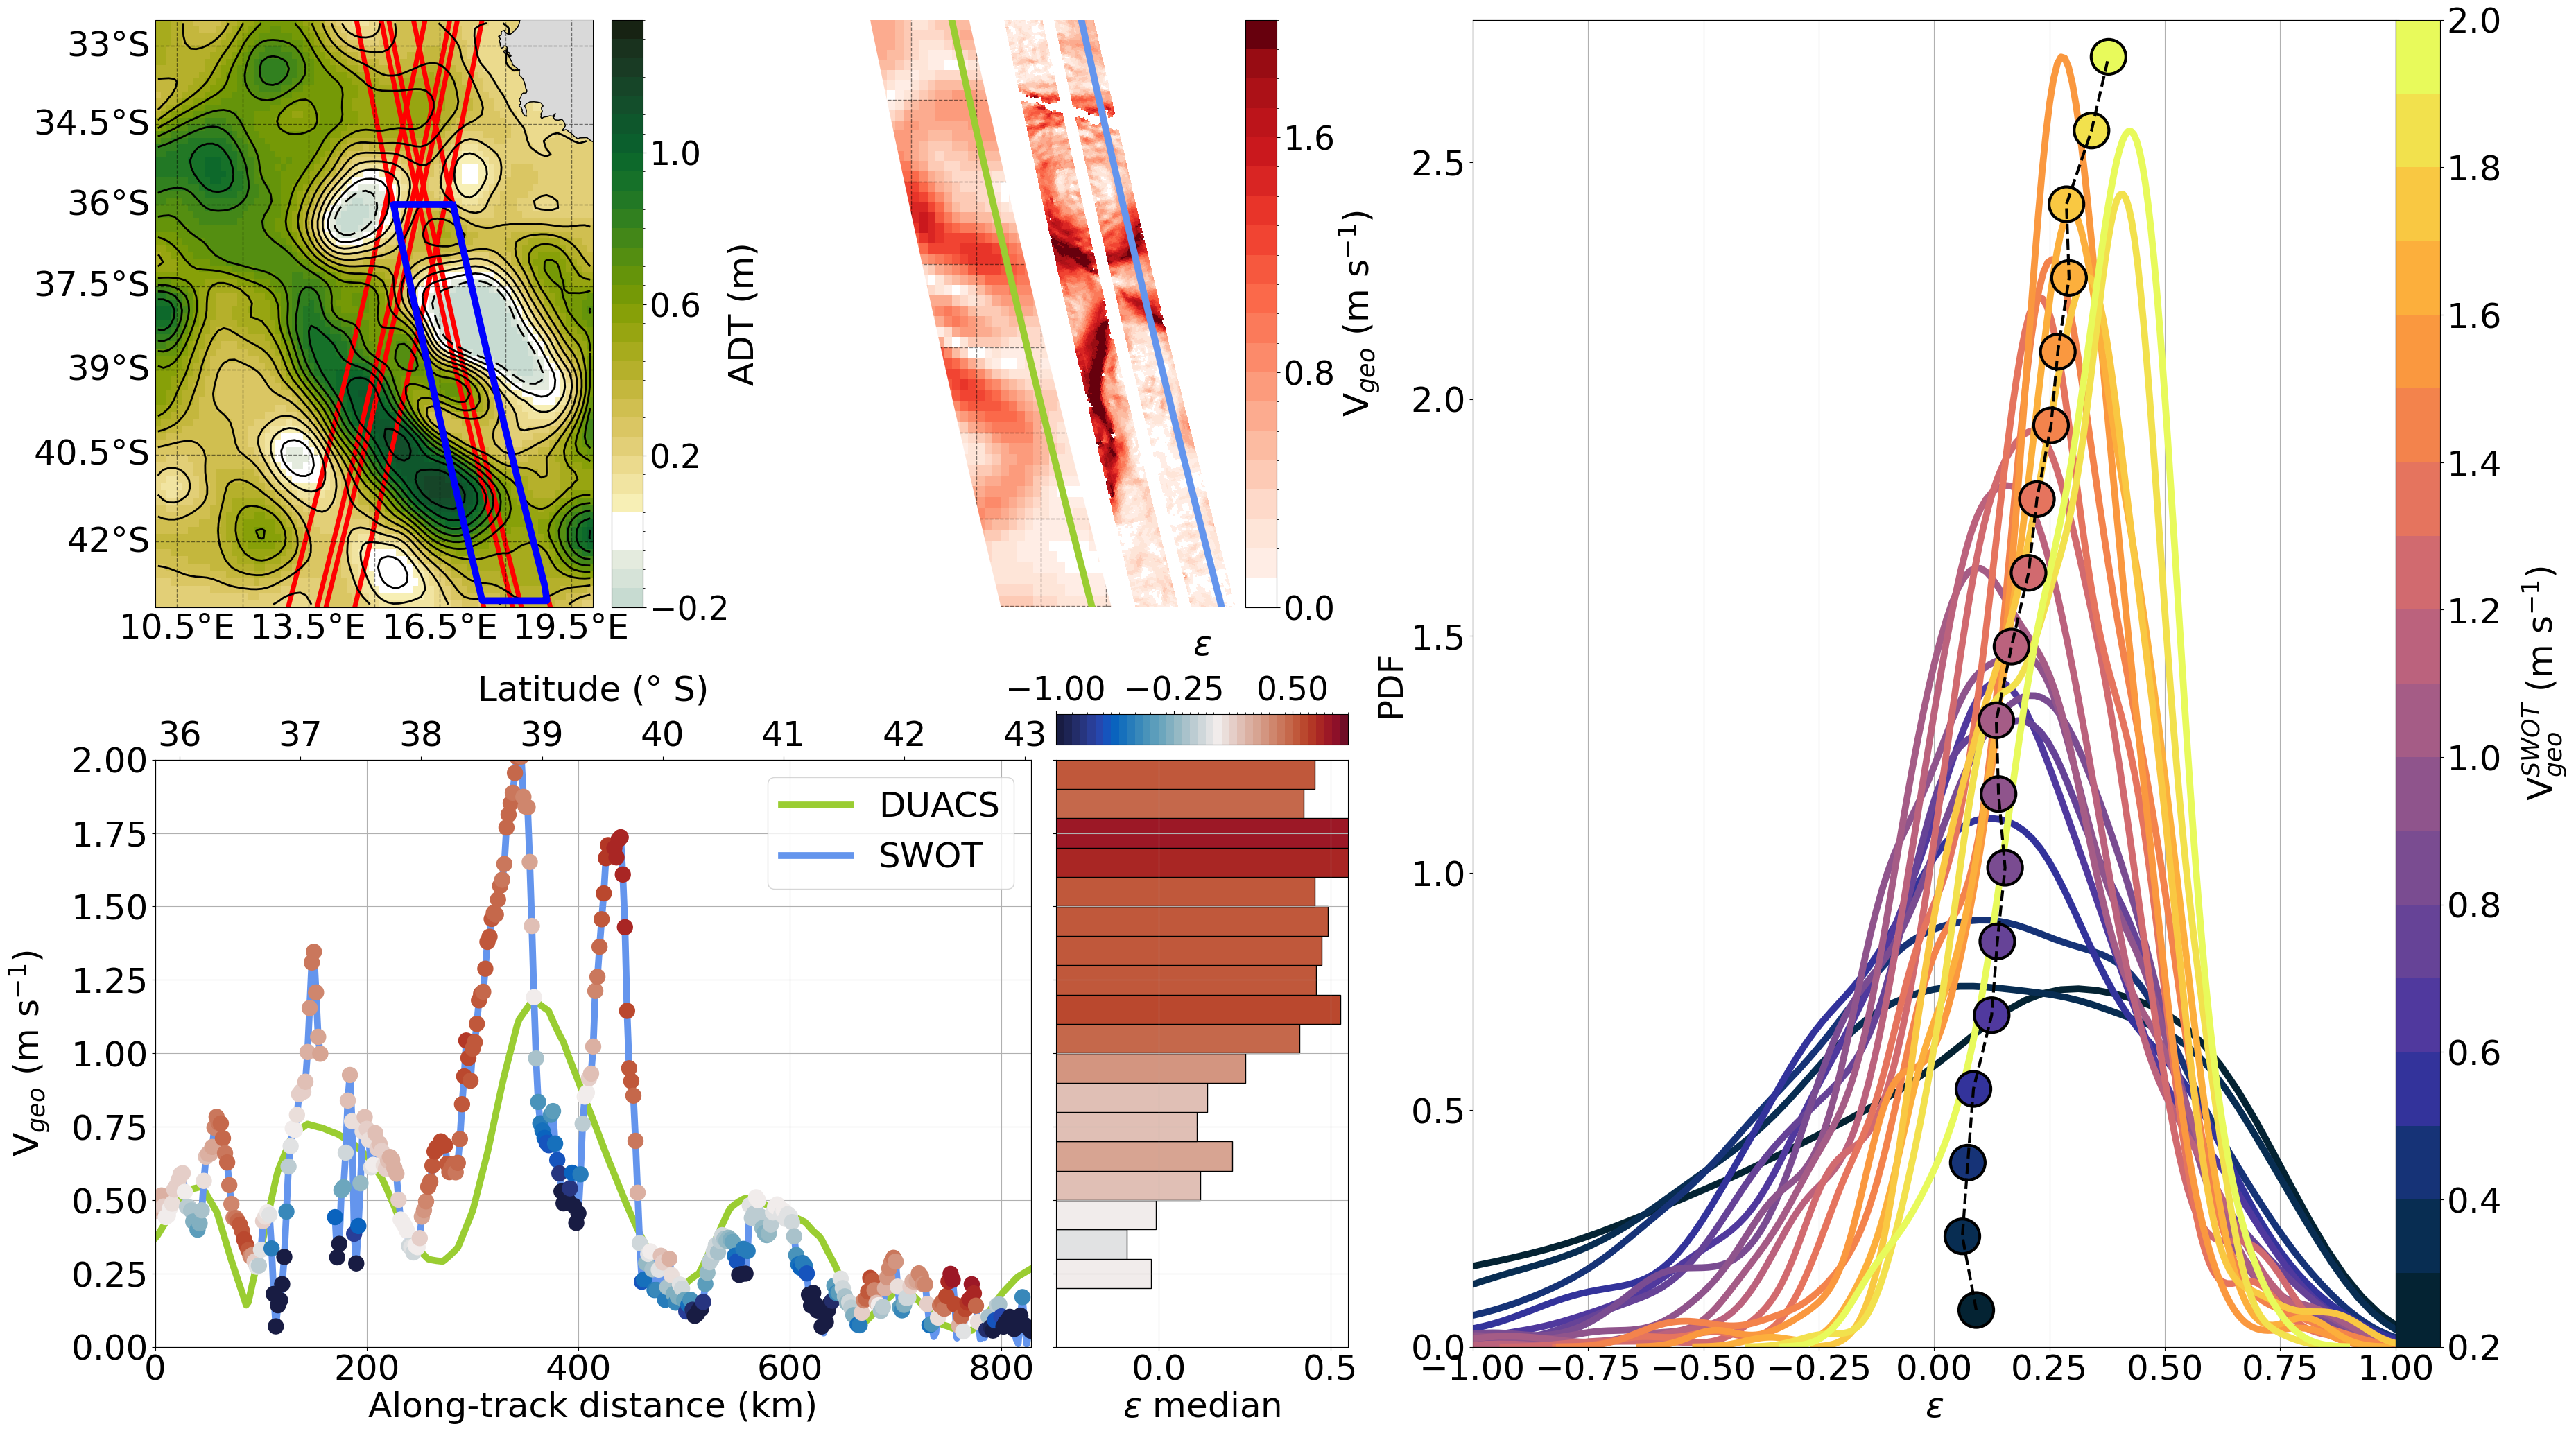

In [74]:
fig=plt.figure(figsize=(9,11))

###Plot regional DUACS ADT map

proj = ccrs.Mercator(central_longitude=15, min_latitude=-45, max_latitude=-32.5)
crs = ccrs.PlateCarree()
pos_west, pos_east, pos_south, pos_north  = 10, 20, -43, -32.5  #Reset the area
extent = [pos_west, pos_east, pos_south, pos_north]
cartmap = proj, crs, extent

ax0 = fig.add_subplot(1, 1, 1,projection=proj, zorder=8)
ax0.add_feature(cfeature.LAND,linewidth=0.5,zorder=4, edgecolor='black', facecolor=(0.85,0.85,0.85))#facecolor=(0.95,0.95,0.95))#,alpha=0.1)
ax0.coastlines(resolution='10m', color='k', linestyle='-', alpha=1,zorder=5)
ax0.set_extent(extent)
map_grid=ax0.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=True,zorder=6)
map_grid.xlabel_style = {'size': ft}
map_grid.ylabel_style = {'size': ft}
map_grid.top_labels = False
map_grid.right_labels = False

im = ax0.pcolormesh(ds_sat.longitude,ds_sat.latitude,ds_sat.adt,cmap=cmap_SSH, norm=norm_SSH,transform=crs)
ax0.contour(ds_sat.longitude, ds_sat.latitude, ds_sat.adt, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2,transform=crs,zorder=15)

    #Add SWOT tracks
swot_Pass_001 = xr.open_dataset([x for x in glob(swot_dir+'*'+'_001_'+'*.nc')][0])
for t in [4,30,38,64]:
    ax0.plot(swot_data.longitude[:,t], swot_data.latitude[:,t], 'r', linewidth=5, transform=crs)
    ax0.plot(swot_Pass_001.longitude[:,t], swot_Pass_001.latitude[:,t], 'r', linewidth=5, transform=crs)
    
    #Add colorbar
pos0 = ax0.get_position()
cax = fig.add_axes([pos0.x0+pos0.width+0.03, pos0.y0, 0.05,pos0.height])
cbar = fig.colorbar(im,cax=cax, orientation='vertical',ticks=Tinc_SSH[::8])
cbar.set_label('ADT (m)', fontsize=ft, labelpad=-2)
cbar.ax.tick_params(labelsize=ft-2)

###Plot zoom DUACS & SWOT velocity

    #Reset projection
proj = ccrs.Mercator(central_longitude=18.125, min_latitude=-45, max_latitude=-30.5)
crs = ccrs.PlateCarree()
pos_west, pos_east, pos_south, pos_north  = 15, 21.25, -43, -36  #Reset the area
extent = [pos_west, pos_east, pos_south, pos_north]
cartmap = proj, crs, extent
    
    #Add location of the zoom on the regional DUACS ADT map
id_select = np.unique(np.where((swot_data.longitude>pos_west) & (swot_data.longitude<pos_east) & (swot_data.latitude>pos_south) & (swot_data.latitude<pos_north))[0])
poly_right_lon = np.concatenate((swot_data.longitude.data[id_select][0,4:65],swot_data.longitude.data[id_select][1:399,64],swot_data.longitude.data[id_select][399,63:1:-1],swot_data.longitude.data[id_select][399:13:-1,4]))
poly_right_lat = np.concatenate((-36*np.ones_like(swot_data.longitude.data[id_select][0,4:65]),swot_data.latitude.data[id_select][1:399,64],-43*np.ones_like(swot_data.longitude.data[id_select][399,63:1:-1]),swot_data.latitude.data[id_select][399:13:-1,4]))
ax0.plot(poly_right_lon, poly_right_lat, 'b',linewidth=7, transform=crs, zorder=22);

    #Set axe
ax1 = fig.add_axes([pos0.x0+pos0.width+0.38, pos0.y0, pos0.width, pos0.height],projection=proj)
ax1.set_extent(extent)
map_grid=ax1.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=False,zorder=6)
ax1.set_frame_on(False)
    
    #Plot DUACS
im = ax1.pcolormesh(ds_sat.longitude,ds_sat.latitude,np.sqrt(ds_sat.ugos**2 + ds_sat.vgos**2), cmap=cmap_V, norm=norm_V, transform=crs)
        
        #Add SWOT track line
ax1.plot(swot_data.longitude[id_select][:,id_track], swot_data.latitude[id_select][:,id_track], 'yellowgreen', linewidth=7, transform=crs, zorder=22);

        #Mask data outside SWOT tracks

            #Define the patches
lon_array_right = np.concatenate((swot_data.longitude[id_select,0],[22,22,swot_data.longitude[id_select[0],0]]))
lat_array_right = np.concatenate((swot_data.latitude[id_select,0],[swot_data.latitude[id_select[-1],0],swot_data.latitude[id_select[0],0],swot_data.latitude[id_select[0],0]]))
right = np.column_stack((lon_array_right, lat_array_right)) # Reshape coordinates
patch_right = Polygon(right) # create polygon
lon_array_left = np.concatenate((swot_data.longitude[id_select,-1],[14,14,swot_data.longitude[id_select[0],-1]]))
lat_array_left = np.concatenate((swot_data.latitude[id_select,-1],[swot_data.latitude[id_select[-1],-1],swot_data.latitude[id_select[0],-1],swot_data.latitude[id_select[0],-1]]))
left = np.column_stack((lon_array_left, lat_array_left)) # Reshape coordinates
patch_left = Polygon(left) # create polygon

            #Plot the patches
ax1.add_geometries([patch_right], crs=crs, facecolor='w',edgecolor='w', zorder=30)
ax1.add_geometries([patch_left], crs=crs, facecolor='w',edgecolor='w', zorder=30)

    #Plot SWOT - shift in longitude on the same axis
field = swot_data.ssha_filtered.data[id_select] + swot_data.mdt.data[id_select]
speed_swot = np.sqrt(swot_data.ugos_filtered.data[id_select]**2 + swot_data.vgos_filtered.data[id_select]**2)
ax1.pcolormesh(swot_data.longitude.data[id_select]+2, swot_data.latitude.data[id_select], speed_swot, cmap=cmap_V, norm=norm_V, transform=crs, zorder=40)
        #Add SWOT track line
ax1.plot(swot_data.longitude[id_select][:,id_track]+2,swot_data.latitude[id_select][:,id_track], 'cornflowerblue',linewidth=7,transform=crs, zorder=42);

    #Add Colorbar
pos1 = ax1.get_position()
label_colorbar = 'V$_{geo}$ (m s$^{-1}$)'
cax = fig.add_axes([pos1.x0+pos1.width-0.01, pos1.y0, 0.05, pos1.height])
cbar = fig.colorbar(im,cax=cax, orientation='vertical',ticks=Tinc_V[::8])
cbar.set_label(label_colorbar, fontsize=ft,labelpad=2)
cbar.ax.tick_params(labelsize=ft-2)

### Add extracted velocities for SWOT and DUACS along the displayed track

    #Set axe
ax3 = fig.add_axes([pos0.x0, pos0.y0-pos0.height-0.2, 2*pos0.width, pos0.height])

    #Interpolate DUACS along SWOT track
lon_swot, lat_swot = swot_data.longitude.data[id_select][:,id_track], swot_data.latitude.data[id_select][:,id_track]
x = xr.DataArray(lon_swot,dims="new_coord")
y = xr.DataArray(lat_swot,dims="new_coord")
dist_swot = np.hstack([0,np.cumsum(sw.dist(lat_swot,lon_swot,units='km')[0])])

field_gridded = np.sqrt(ds_sat.ugos**2 + ds_sat.vgos**2).interp(longitude=x, latitude=y).compute().data

    #Plot DUACS and SWOT along SWOT track
ax3.plot(dist_swot, field_gridded, 'yellowgreen', linewidth=7, label='DUACS')
field_swot = np.sqrt(swot_data.ugos_filtered.data[id_select][:,id_track]**2 + swot_data.vgos_filtered.data[id_select][:,id_track]**2)
        #Add SWOT track line
ax3.plot(dist_swot, field_swot, 'cornflowerblue', linewidth=7, label='SWOT')

    #Set plot parameters
plt.xlim(0,dist_swot[-1])
plt.ylim(0,2)
plt.grid()
plt.legend(fontsize=ft)
ax3.tick_params(labelsize=ft)
plt.xlabel('Along-track distance (km)', fontsize=ft)
plt.ylabel('V$_{geo}$ (m s$^{-1}$)', fontsize=ft, labelpad=20)

    #Plot epsilon values
id_nan = np.where(field_swot<0.05)
field_swot[id_nan] = np.nan
epsilon = (field_swot-field_gridded)/field_swot
im = ax3.scatter(dist_swot, field_swot, 250, c=epsilon, cmap=cmap_eps, norm=norm_eps, zorder=10)

    #Add latitude as second x-axis
ax3ghost=ax3.twiny()
ax3ghost.plot(-lat_swot, field_swot, alpha=0)
ax3ghost.set_xlim(-lat_swot[0], -lat_swot[-1])
ax3ghost.tick_params(labelsize=ft)
plt.xlabel('Latitude (° S)', fontsize=ft, labelpad=20)

###Add median epsilon values binned binned by SWOT velocities 
### for the the selected day and track

    #Set axe
pos3=ax3.get_position()
ax3bis = fig.add_axes([pos3.x0+pos3.width+0.04, pos3.y0, 1/3*pos3.width, pos3.height])

    #Plot
for vel in range(len(speed_bins)-1):
    vel_select = np.where((field_swot>=speed_bins[vel]) & (field_swot<speed_bins[vel+1]))[0]
    med = np.nanmedian(epsilon[vel_select])
    
    x_array = [-5, med, med, -5, -5]
    y_array = [speed_bins[vel], speed_bins[vel], speed_bins[vel+1], speed_bins[vel+1], speed_bins[vel]]
    
    icol = np.where(Tinc_eps>=med)[0][0]
    ax3bis.fill(x_array, y_array, facecolor=cmap_eps(icol),edgecolor='k')

    #Set plot parameters
ax3bis.tick_params(labelsize=ft)
plt.ylim(0,2)
plt.xlim(-0.3, 0.55)
plt.xlabel('$\epsilon$ median', fontsize=ft)
ax3bis.set_yticklabels([])
plt.grid()

    #Add Colorbar
pos3bis=ax3bis.get_position()
label_colorbar = '$\epsilon$'
cax = fig.add_axes([pos3bis.x0, pos3bis.y0 + pos3bis.height+0.02, pos3bis.width, 0.04])
cbar = fig.colorbar(im,cax=cax, orientation='horizontal',ticks=Tinc_eps[::15])
cbar.set_label(label_colorbar, fontsize=ft,labelpad=20)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')
cbar.ax.tick_params(labelsize=ft-2)

###Probability density distributions of epsilon for different SWOT velocities

    #Set axe
ax4 = fig.add_axes([pos3bis.x0+pos3bis.width+0.2, pos3bis.y0, 2*pos3bis.height+0.2, 2*pos3bis.height+0.2])

    #Store DUACS and SWOT velocities over the full fast-sampling phase along id_track
hov_swot = np.zeros([len(id_select), len(swot_files)])
hov_duacs = np.zeros([len(id_select), len(swot_files)])

hov_swot[:] = np.nan
hov_duacs[:] = np.nan

        #Loop over the full fast-sampling phase
for i in tqdm(range(len(swot_files))):
    
        #SWOT file
    tem = xr.open_dataset(swot_files[i])
    field_swot = np.sqrt(tem.ugos_filtered.data[id_select][:,id_track]**2 + tem.vgos_filtered.data[id_select][:,id_track]**2)
            
        #DUACS file
    textlabel = swot_files[i][-41:-37] + '-' + swot_files[i][-37:-35] + '-' + swot_files[i][-35:-33] 
    date64 = np.datetime64(datetime(int(swot_files[i][-41:-37]), int(swot_files[i][-37:-35]), int(swot_files[i][-35:-33])))   
    ds_sat = ds_ssh.sel(time=date64)
        
        #Interpolate DUACS
    field_gridded = np.sqrt(ds_sat.ugos**2 + ds_sat.vgos**2).interp(longitude=x, latitude=y).compute().data
    
    hov_swot[:,i] = field_swot
    hov_duacs[:,i] = field_gridded

    #Set plot parameters
plt.xlim(-1,1)
plt.xlabel('$\epsilon$', fontsize=ft)
plt.ylabel('PDF', fontsize=ft)
plt.gca().tick_params(labelsize=ft)
plt.ylim(0,2.8)
plt.grid(axis='x')

    #Plot
mean_diff = np.zeros(len(speed_bins)-1) #Median values of epsilon for each distribution

        #PDF
for s in range(len(speed_bins)-1):
    rows_sel, cols_sel = np.where((hov_swot>=speed_bins[s]) & (hov_swot<speed_bins[s+1]))

    select_velocity = np.zeros_like(hov_duacs)
    select_velocity[:] = np.nan
    select_velocity[rows_retro,cols_retro] = hov_swot[rows_sel, cols_sel]
    sns.kdeplot(((select_velocity-hov_duacs)/hov_swot).flatten(),color=cmap_pdf(s), linewidth=7)

    mean_diff[s]=np.nanmedian(((select_velocity-hov_duacs)/hov_swot))

        #Median
ax = plt.gca().twinx()
sc = plt.scatter(mean_diff, speed_bins[:-1]+step/2, c=speed_bins[:-1]+step/2, vmin=speed_bins[0], vmax=speed_bins[-1], s=1300, cmap=cmap_pdf, edgecolors='k', linewidth=3)

    #Add colorbar
cbar = plt.colorbar(sc, pad=0, ticks=speed_bins[::2], aspect=30)
cbar.set_label('V$_{geo}^{SWOT}$ (m s$^{-1}$)', fontsize=ft, labelpad=20)
cbar.ax.tick_params(labelsize=ft)

    #Set plot parameters
ax.set_yticklabels([])
plt.ylim(speed_bins[0],speed_bins[-1])
ax.plot(mean_diff, speed_bins[:-1]+step/2, 'k--', linewidth=3)
plt.gca().tick_params(labelsize=ft)

#fig.savefig(path_save +'Figure_2_submission.png',bbox_inches='tight',dpi=300)
